In [1]:
## Regularization Techniques  --- Ridge - Lasso - Elastic Net

In [2]:
## Not to reduce error, increase the error slightly

In [18]:
# import necessary libraries

import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

In [5]:
data = fetch_california_housing()

In [6]:
data

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [7]:
house_df = pd.DataFrame(data= data.data, columns=data.feature_names)
house_df["target"] = data.target
house_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [8]:
house_df.shape

(20640, 9)

In [9]:
house_df.dtypes

MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
target        float64
dtype: object

In [10]:
house_df.isna().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
target        0
dtype: int64

In [11]:
X = house_df.drop(labels="target",axis=1)
y = house_df["target"]

In [13]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=101)

In [14]:
linear_model = LinearRegression()
ridge_model = Ridge(alpha=0.1)
lasso_model = Lasso(alpha=1.0)
elastic_net_model = ElasticNet(
    alpha=1.0,l1_ratio=0.5
)

In [16]:
linear_model.fit(X_train,y_train)
ridge_model.fit(X_train,y_train)
lasso_model.fit(X_train,y_train)
elastic_net_model.fit(X_train,y_train)

,alpha,1.0
,l1_ratio,0.5
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [17]:
print("Linear Regression Coefficients:\n",linear_model.coef_)
print("Ridge Coefficients:\n",ridge_model.coef_)
print("Lasso Coefficients:\n",lasso_model.coef_)
print("Elastic Net Coefficients:\n",elastic_net_model.coef_)

Linear Regression Coefficients:
 [ 4.35942782e-01  9.66161365e-03 -1.07190554e-01  6.04821496e-01
 -4.34745213e-06 -4.10947310e-03 -4.15463799e-01 -4.28700232e-01]
Ridge Coefficients:
 [ 4.35930957e-01  9.66182354e-03 -1.07167832e-01  6.04704772e-01
 -4.34647216e-06 -4.10942812e-03 -4.15462171e-01 -4.28697021e-01]
Lasso Coefficients:
 [ 1.45494424e-01  6.19510601e-03  0.00000000e+00 -0.00000000e+00
 -3.55903134e-06 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00]
Elastic Net Coefficients:
 [ 2.53312896e-01  1.17196777e-02  0.00000000e+00 -0.00000000e+00
  1.29436063e-05 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00]


In [19]:
# Function to plot coefficients
def plot_coefficients(model, feature_names, title):
    
    coef_df = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": model.coef_
    })

    coef_df = coef_df.sort_values(by="Coefficient")
    print(coef_df)
        
    plt.figure(figsize=(10,6))
    plt.barh(coef_df["Feature"], coef_df["Coefficient"])
    
    plt.title(title)
    plt.xlabel("Coefficient Value")
    plt.ylabel("Features")
    
    plt.tight_layout()
    plt.show()

      Feature  Coefficient
7   Longitude    -0.428700
6    Latitude    -0.415464
2    AveRooms    -0.107191
5    AveOccup    -0.004109
4  Population    -0.000004
1    HouseAge     0.009662
0      MedInc     0.435943
3   AveBedrms     0.604821


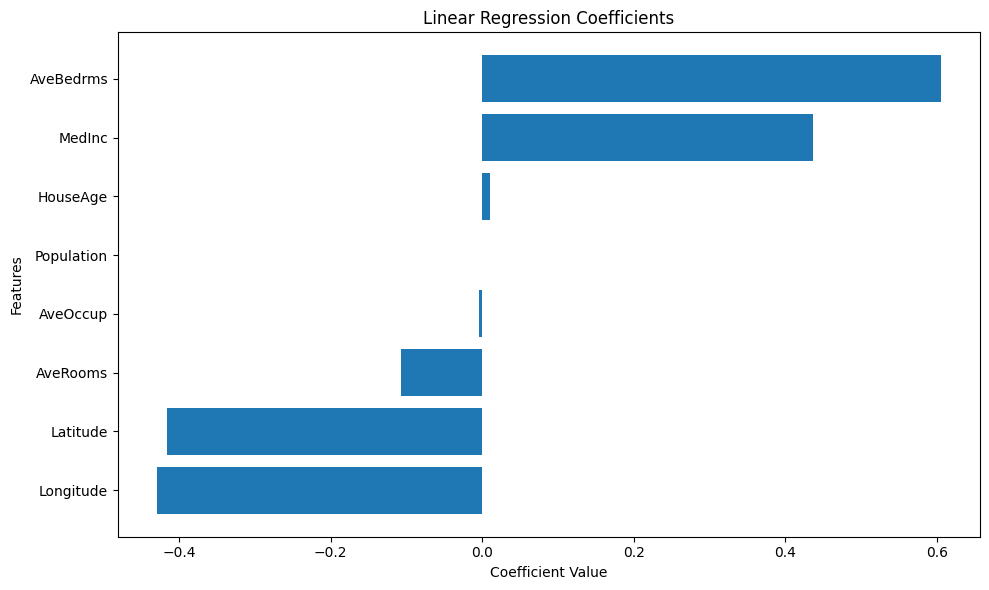

In [21]:
# Linear Regression
plot_coefficients(
    linear_model,
    X.columns,
    "Linear Regression Coefficients"
)

      Feature  Coefficient
7   Longitude    -0.428697
6    Latitude    -0.415462
2    AveRooms    -0.107168
5    AveOccup    -0.004109
4  Population    -0.000004
1    HouseAge     0.009662
0      MedInc     0.435931
3   AveBedrms     0.604705


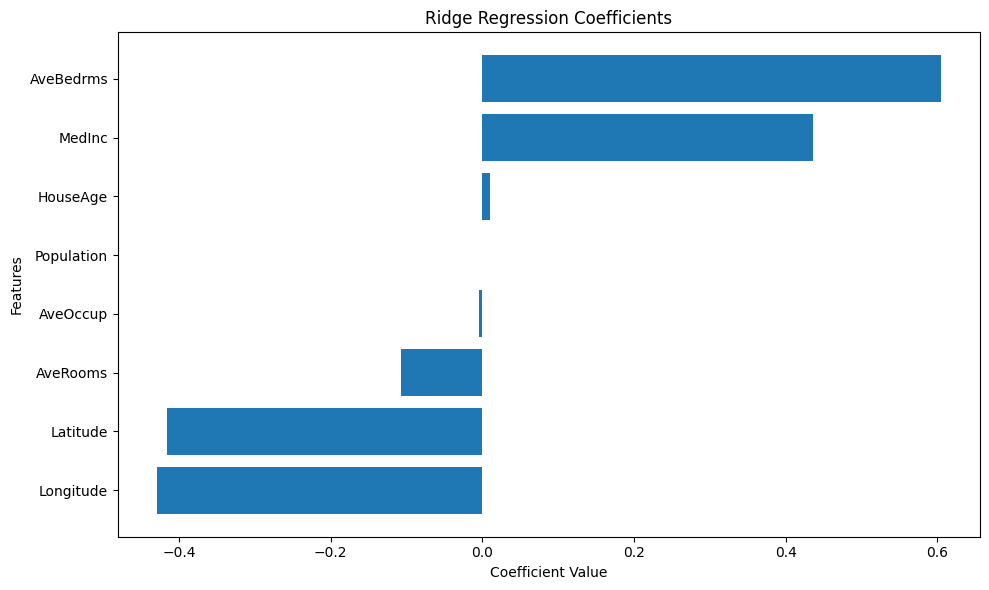

In [22]:

# Ridge Regression
plot_coefficients(
    ridge_model,
    X.columns,
    "Ridge Regression Coefficients"
)


      Feature  Coefficient
4  Population    -0.000004
3   AveBedrms    -0.000000
5    AveOccup    -0.000000
2    AveRooms     0.000000
6    Latitude    -0.000000
7   Longitude    -0.000000
1    HouseAge     0.006195
0      MedInc     0.145494


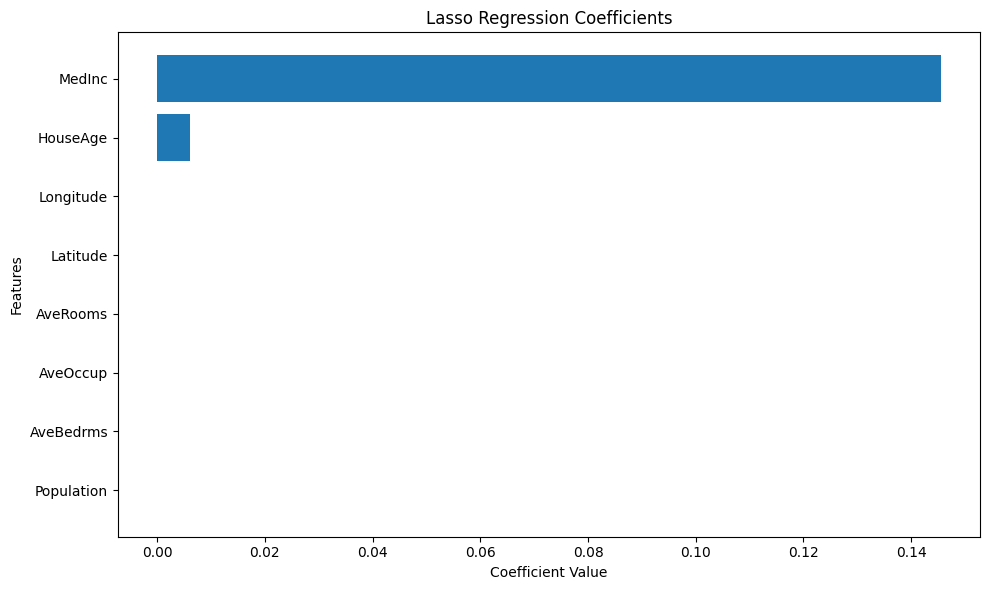

In [23]:

# Lasso Regression
plot_coefficients(
    lasso_model,
    X.columns,
    "Lasso Regression Coefficients"
)


      Feature  Coefficient
3   AveBedrms    -0.000000
2    AveRooms     0.000000
6    Latitude    -0.000000
5    AveOccup    -0.000000
7   Longitude    -0.000000
4  Population     0.000013
1    HouseAge     0.011720
0      MedInc     0.253313


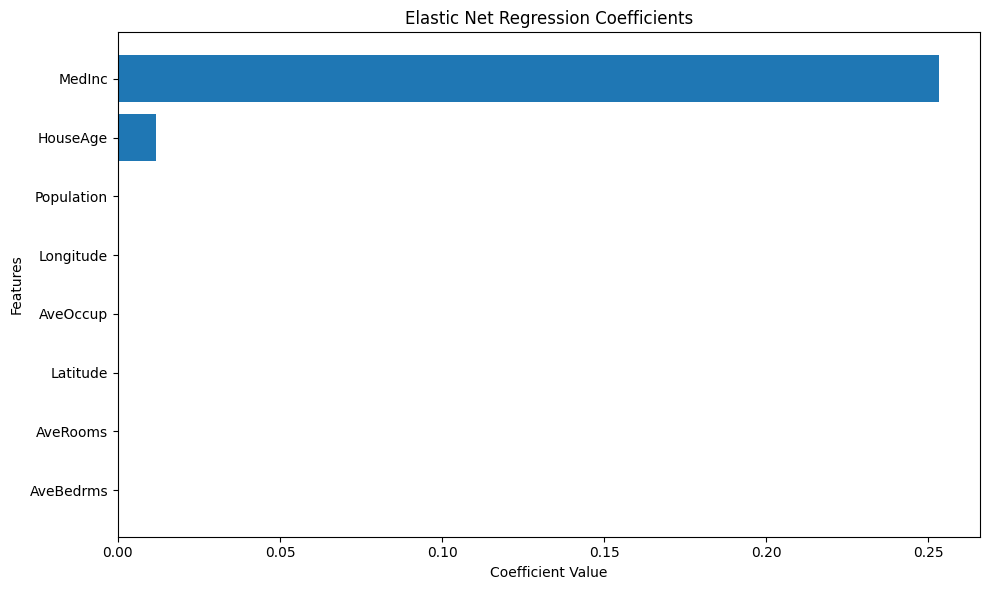

In [25]:

# Elastic Net
plot_coefficients(
    elastic_net_model,
    X.columns,
    "Elastic Net Regression Coefficients"
)

      Feature  Coefficient
7   Longitude    -0.428700
6    Latitude    -0.415464
2    AveRooms    -0.107191
5    AveOccup    -0.004109
4  Population    -0.000004
1    HouseAge     0.009662
0      MedInc     0.435943
3   AveBedrms     0.604821


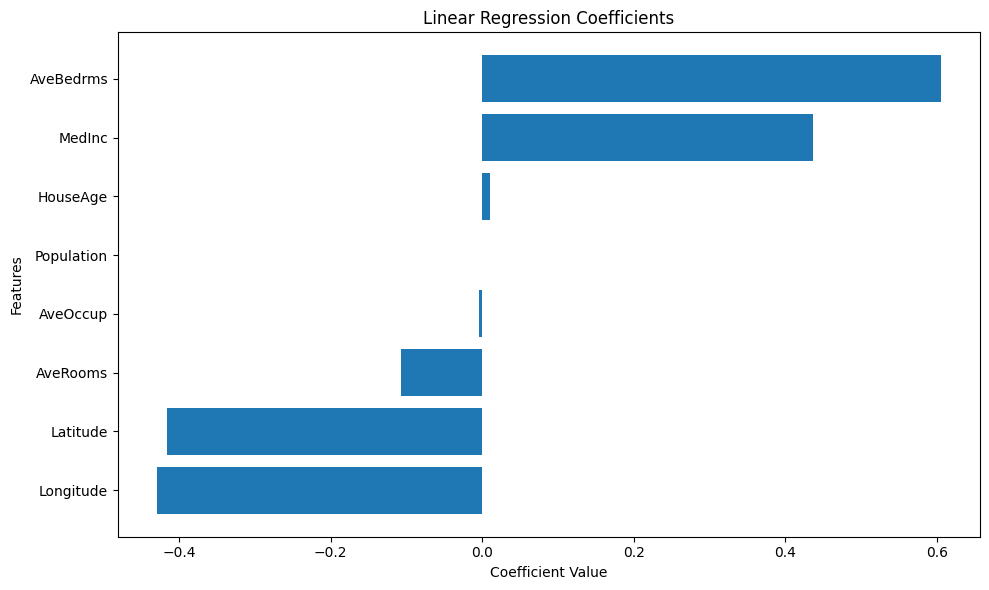

      Feature  Coefficient
7   Longitude    -0.428697
6    Latitude    -0.415462
2    AveRooms    -0.107168
5    AveOccup    -0.004109
4  Population    -0.000004
1    HouseAge     0.009662
0      MedInc     0.435931
3   AveBedrms     0.604705


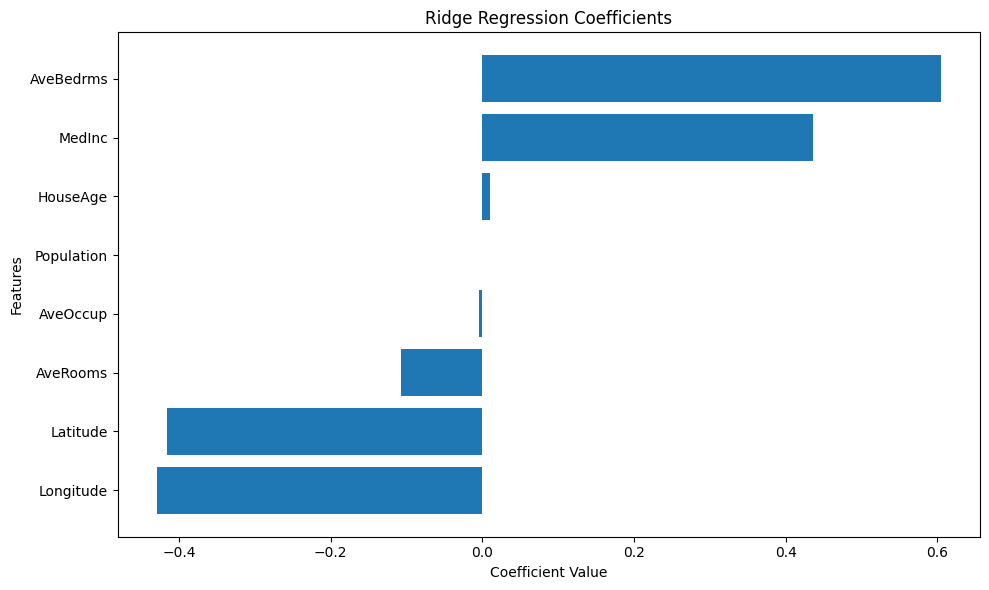

      Feature  Coefficient
4  Population    -0.000004
3   AveBedrms    -0.000000
5    AveOccup    -0.000000
2    AveRooms     0.000000
6    Latitude    -0.000000
7   Longitude    -0.000000
1    HouseAge     0.006195
0      MedInc     0.145494


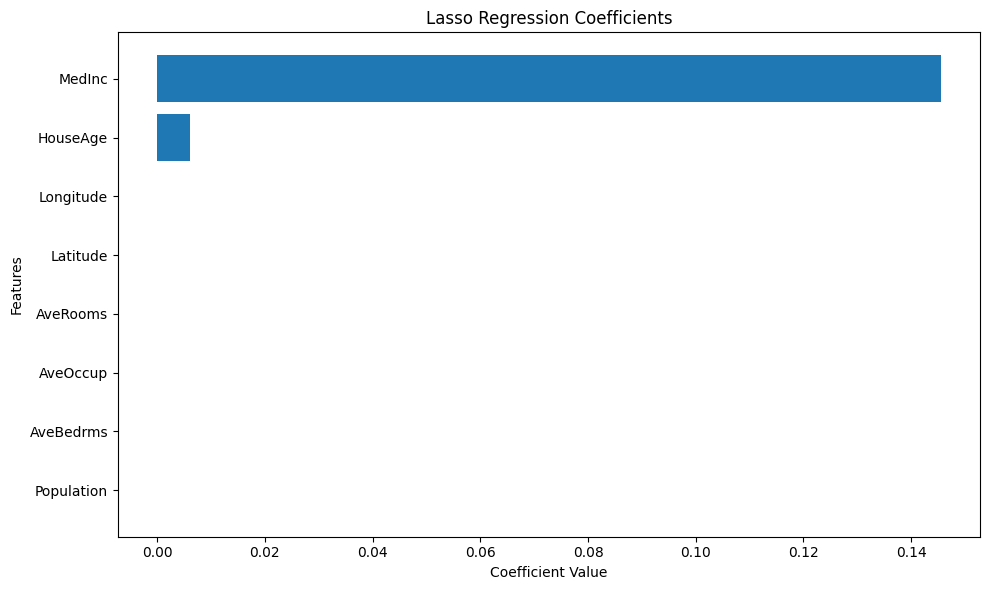

NameError: name 'elastic_model' is not defined

In [26]:
import matplotlib.pyplot as plt

# Function to plot coefficients
def plot_coefficients(model, feature_names, title):
    
    coef_df = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": model.coef_
    })

    coef_df = coef_df.sort_values(by="Coefficient")
    print(coef_df)
        
    plt.figure(figsize=(10,6))
    plt.barh(coef_df["Feature"], coef_df["Coefficient"])
    
    plt.title(title)
    plt.xlabel("Coefficient Value")
    plt.ylabel("Features")
    
    plt.tight_layout()
    plt.show()


# Linear Regression
plot_coefficients(
    linear_model,
    X.columns,
    "Linear Regression Coefficients"
)

# Ridge Regression
plot_coefficients(
    ridge_model,
    X.columns,
    "Ridge Regression Coefficients"
)

# Lasso Regression
plot_coefficients(
    lasso_model,
    X.columns,
    "Lasso Regression Coefficients"
)

# Elastic Net
plot_coefficients(
    elastic_model,
    X.columns,
    "Elastic Net Regression Coefficients"
)